# DJIA Stock Returns Analysis

## What This Notebook Is About

This notebook builds a **complete financial data pipeline from scratch**:
1. Scrape the 30 Dow Jones Industrial Average (DJIA) ticker symbols from Wikipedia
2. Download 5 years of daily adjusted prices from Yahoo Finance
3. Calculate daily log returns and monthly arithmetic returns
4. Analyse risk vs. return, correlations, and rolling volatility

---

### What Are Stock Returns?

A **return** measures how much an investment gained or lost:
- **Simple return**: `(P_today − P_yesterday) / P_yesterday` = % change in price
- **Log return**: `ln(P_today / P_yesterday)` ≈ simple return for small values

**Why use log returns?**
- Log returns are *additive* over time: monthly log return = sum of daily log returns
- They are approximately normally distributed (useful for statistics)
- Simple returns cannot fall below −100%, but log returns are symmetric

---

### What Is Risk?

In finance, **risk** is measured by the **standard deviation (SD) of returns**:
- High SD = prices fluctuate a lot = higher risk
- Low SD = stable prices = lower risk

The classic **risk-return trade-off**: higher expected return almost always comes with higher risk. Investors must decide how much volatility they're willing to accept.

---

### What Is SPY?

**SPY** is the SPDR S&P 500 ETF — it tracks the S&P 500 index (the 500 largest US companies). We include it as a **benchmark**: if your stock portfolio doesn't beat SPY, you might as well just buy SPY.

---

### What You Will Learn

| Concept | Where |
|---|---|
| `requests` + `pd.read_html()`: scraping a table from Wikipedia | Section: Scrape tickers |
| `yf.download()` multi-ticker download + stacking | Section: Download prices |
| Log returns: `np.log(x / x.shift(1))` via `.transform()` | Section: Log returns |
| Monthly resampling: `.resample('ME').last()` + `pct_change()` | Section: Monthly returns |
| FacetGrid with PercentFormatter for return histograms | Section: Histograms |
| CI dot-and-whisker plot with `ax.errorbar()` | Section: CI plot |
| Total return index: `(1 + r).cumprod() * 100` | Section: Total return |

---

### Libraries Used
- **`yfinance`** — download historical stock prices from Yahoo Finance
- **`requests`** + **`pandas.read_html()`** — web scraping
- **`numpy`** — `np.log()` for log returns
- **`pandas`** — `resample`, `pct_change`, `pivot_table`, `groupby`
- **`seaborn`** / **`matplotlib`** — FacetGrid histograms, ECDF, heatmap, line plots

In [1]:
# --- Import libraries ---
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from datetime import date, timedelta
from dateutil.relativedelta import relativedelta
import yfinance as yf

import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

In [3]:
# =============================================================================
# SECTION: Scrape DJIA ticker symbols from Wikipedia
# =============================================================================
# The DJIA has 30 constituent stocks that change over time. Rather than hard-
# coding a list (which would go stale), we scrape the current list from Wikipedia.
#
# SCRAPING STRATEGY:
#   1. requests.get(url): download the raw HTML of the Wikipedia page
#   2. pd.read_html(): extract ALL <table> tags from the HTML into a list of DataFrames
#   3. Pick the right table (index [1] = the second table on the page)
#
# WHY NOT JUST USE pd.read_html(url) DIRECTLY?
#   Wikipedia blocks automated scrapers. The 'User-Agent' header makes our
#   request look like it came from a real browser — without it, Wikipedia
#   returns a 403 Forbidden error.
#
# pd.read_html():
#   - Takes an HTML string (or URL) and returns a LIST of DataFrames
#   - Each DataFrame corresponds to one <table> element on the page
#   - We use StringIO() to pass the HTML string (instead of re-fetching the URL)
#   - tables[1]: the second table = the DJIA components table
#
# response.raise_for_status():
#   If the HTTP request failed (e.g. 404, 403), this raises an exception immediately.
#   Without it, the code would silently continue with a broken response.

import requests
from io import StringIO

# Browser-like User-Agent header so Wikipedia doesn't block us
headers = {"User-Agent": "Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) AppleWebKit/537.36"}
djia_url = 'https://en.wikipedia.org/wiki/Dow_Jones_Industrial_Average'

response = requests.get(djia_url, headers=headers)
response.raise_for_status()   # raise an error if the download failed

# Parse ALL tables from the HTML page
tables = pd.read_html(StringIO(response.text))

# The second table (index=1) contains the list of DJIA components
table1 = tables[1].copy()
print('Columns:', table1.columns.tolist())
table1.head(10)

Columns: ['Company', 'Exchange', 'Symbol', 'Sector', 'Date added', 'Notes', 'Index weighting']


,Company,Exchange,Symbol,Sector,Date added,Notes,Index weighting
0,3M,NYSE,MMM,Industrials,1976-08-09,As Minnesota Mining and Manufacturing,2.17%
1,American Express,NYSE,AXP,Financials,1982-08-30,NaN,4.31%
2,Amgen,NASDAQ,AMGN,Health Care,2020-08-31,NaN,4.14%
3,Amazon,NASDAQ,AMZN,Consumer Discretionary,2024-02-26,NaN,2.99%
4,Apple,NASDAQ,AAPL,Information Technology,2015-03-19,NaN,2.92%
5,Boeing,NYSE,BA,Industrials,1987-03-12,NaN,3.03%
6,Caterpillar,NYSE,CAT,Industrials,1991-05-06,NaN,5.13%
7,Chevron,NYSE,CVX,Energy,2008-02-19,Also 1930-07-18 to 1999-11-01,2.01%
8,Cisco,NASDAQ,CSCO,Information Technology,2009-06-08,NaN,0.92%
9,Coca-Cola,NYSE,KO,Consumer Staples,1987-03-12,Also 1932-05-26 to 1935-11-20,1.04%


In [4]:
# --- Extract clean ticker symbols ---
# Wikipedia lists symbols as 'NYSE: MMM' for NYSE-listed stocks
# Yahoo Finance just needs the ticker part (e.g. 'MMM')

def clean_ticker(symbol_str):
    """Strip exchange prefix (e.g. 'NYSE: MMM' -> 'MMM')."""
    if isinstance(symbol_str, str) and ':' in symbol_str:
        return symbol_str.split(':')[-1].strip()
    return str(symbol_str).strip()

# Find the column containing ticker symbols (it usually contains ':' for NYSE listings)
ticker_col = [c for c in table1.columns if table1[c].astype(str).str.contains(':').any()]
ticker_col = ticker_col[0] if ticker_col else 'Symbol'

tickers = (
    table1[ticker_col]
    .apply(clean_ticker)
    .dropna()
    .unique()
    .tolist()
)

# Add SPY as a benchmark (tracks the S&P 500)
tickers = tickers + ['SPY']
print(f'Total tickers to download: {len(tickers)}')
print(tickers)

Total tickers to download: 31
['MMM', 'AXP', 'AMGN', 'AMZN', 'AAPL', 'BA', 'CAT', 'CVX', 'CSCO', 'KO', 'DIS', 'GS', 'HD', 'HON', 'IBM', 'JNJ', 'JPM', 'MCD', 'MRK', 'MSFT', 'NKE', 'NVDA', 'PG', 'CRM', 'SHW', 'TRV', 'UNH', 'VZ', 'V', 'WMT', 'SPY']


In [5]:
# --- Define date range: 5 years back from today ---
end_date   = date.today()
start_date = end_date - relativedelta(years=5)
start_date = date(start_date.year, 1, 1)   # snap to Jan 1 of that year

print(f'Download period: {start_date} to {end_date}')

Download period: 2021-01-01 to 2026-03-21


In [6]:
# --- Download adjusted closing prices from Yahoo Finance ---
# yf.download() with multiple tickers returns a multi-level DataFrame
# We stack it into a long 'tidy' format: date | symbol | adjusted

raw = yf.download(
    tickers,
    start=str(start_date),
    end=str(end_date),
    auto_adjust=True,     # adjusted for splits and dividends
    progress=False
)

# Keep only the 'Close' column (= adjusted close when auto_adjust=True)
my_stocks = (
    raw['Close']
    .stack()                               # wide → long
    .reset_index()
    .rename(columns={'level_1': 'symbol', 0: 'adjusted', 'Ticker': 'symbol'})
    .dropna(subset=['adjusted'])
    .sort_values(['symbol', 'Date'])
    .rename(columns={'Date': 'date'})
)

print('my_stocks shape:', my_stocks.shape)
my_stocks.head()

my_stocks shape: (40579, 3)


,date,symbol,adjusted
0,2021-01-04,AAPL,125.856712
31,2021-01-05,AAPL,127.412781
62,2021-01-06,AAPL,123.123856
93,2021-01-07,AAPL,127.325256
124,2021-01-08,AAPL,128.424210


In [9]:
# =============================================================================
# SECTION: Calculate daily log returns
# =============================================================================
# Python equivalent of: tq_transmute(mutate_fun=periodReturn, period='daily', type='log')
#
# LOG RETURN FORMULA:
#   r_t = ln(P_t / P_{t-1}) = ln(P_t) − ln(P_{t-1})
#
# Why log returns?
#   1. Additive: weekly log return = Σ daily log returns (over 5 days)
#   2. Symmetric: a +50% gain followed by a −50% loss ≠ 0 with simple returns,
#      but log returns handle this correctly
#   3. Approximately normal: easier to apply statistical tests
#
# KEY PANDAS PATTERNS:
#
#   .groupby('symbol') + .transform():
#     groupby splits the data by symbol, transform applies the function
#     WITHIN each group, and RETURNS A SERIES WITH THE SAME INDEX as the original.
#     This is critical: the result stays aligned with the original rows.
#
#     Alternative: groupby().apply() exists but changes the index structure.
#     transform() is cleaner when you want to add a new column to the same DataFrame.
#
#   x.shift(1):
#     Shifts values DOWN by 1 row within each group.
#     So row i gets the value from row i-1 (= yesterday's price).
#     Combined with x / x.shift(1): today's price / yesterday's price.
#     The first row per stock gets NaN (no "yesterday") → we dropna() it.
#
#   np.log(x / x.shift(1)):
#     Computes the natural logarithm of the price ratio = log return.

daily_returns = (
    my_stocks
    .sort_values(['symbol', 'date'])  # sort so shift(1) gives the previous day's price
    .assign(
        daily_returns=lambda df: df.groupby('symbol')['adjusted']
                                   .transform(lambda x: np.log(x / x.shift(1)))
                                   # np.log(today/yesterday) = daily log return
    )
    .dropna(subset=['daily_returns'])  # first row per stock has no "previous day"
    [['date', 'symbol', 'daily_returns']]
)

print('Daily returns shape:', daily_returns.shape)
daily_returns.head()

Daily returns shape: (40548, 3)


,date,symbol,daily_returns
31,2021-01-05,AAPL,0.012288
62,2021-01-06,AAPL,-0.034241
93,2021-01-07,AAPL,0.033554
124,2021-01-08,AAPL,0.008594
155,2021-01-11,AAPL,-0.023523


In [10]:
# =============================================================================
# SECTION: Calculate monthly arithmetic returns
# =============================================================================
# We want monthly returns (not daily) for summary statistics.
# Monthly data is less noisy and easier to interpret.
#
# STRATEGY:
#   1. For each stock, find the LAST adjusted price of each calendar month
#   2. Compute the simple % change between consecutive month-end prices
#
# KEY PANDAS OPERATIONS:
#
#   .set_index('date'):
#     resample() works on a DatetimeIndex, so we must set the date column as the index first.
#     After resample, we .reset_index() to restore it as a regular column.
#
#   .resample('ME'):
#     'ME' = Month End. Groups all rows within each calendar month.
#     After grouping: .last() takes the LAST price of each month.
#     Alternative: .first() for first-of-month, .mean() for monthly average.
#
#   .groupby('symbol')['adjusted'].pct_change():
#     pct_change() = (this_value − previous_value) / previous_value
#     This is a SIMPLE return (not log). Used here because monthly returns are
#     commonly expressed as simple % changes (not log).
#     We apply it WITHIN each symbol group so December→January change is computed
#     per stock (not across different stocks).
#
# NOTE: The first month per stock gets NaN (no previous month) → dropna() removes it.

monthly_returns = (
    my_stocks
    .assign(date=lambda df: pd.to_datetime(df['date']))  # ensure date is datetime type
    .set_index('date')         # resample requires a DatetimeIndex
    .groupby('symbol')['adjusted']
    .resample('ME')            # group into calendar months (Month End)
    .last()                    # take the final price of each month
    .reset_index()
    .sort_values(['symbol', 'date'])
    .assign(
        monthly_returns=lambda df: df.groupby('symbol')['adjusted']
                                     .pct_change()     # (this_month − last_month) / last_month
    )
    .dropna(subset=['monthly_returns'])
    [['date', 'symbol', 'monthly_returns']]
)

print('Monthly returns shape:', monthly_returns.shape)
monthly_returns.head()

Monthly returns shape: (1922, 3)


,date,symbol,monthly_returns
1,2021-02-28,AAPL,-0.079712
2,2021-03-31,AAPL,0.007340
3,2021-04-30,AAPL,0.076218
4,2021-05-31,AAPL,-0.050497
5,2021-06-30,AAPL,0.099109


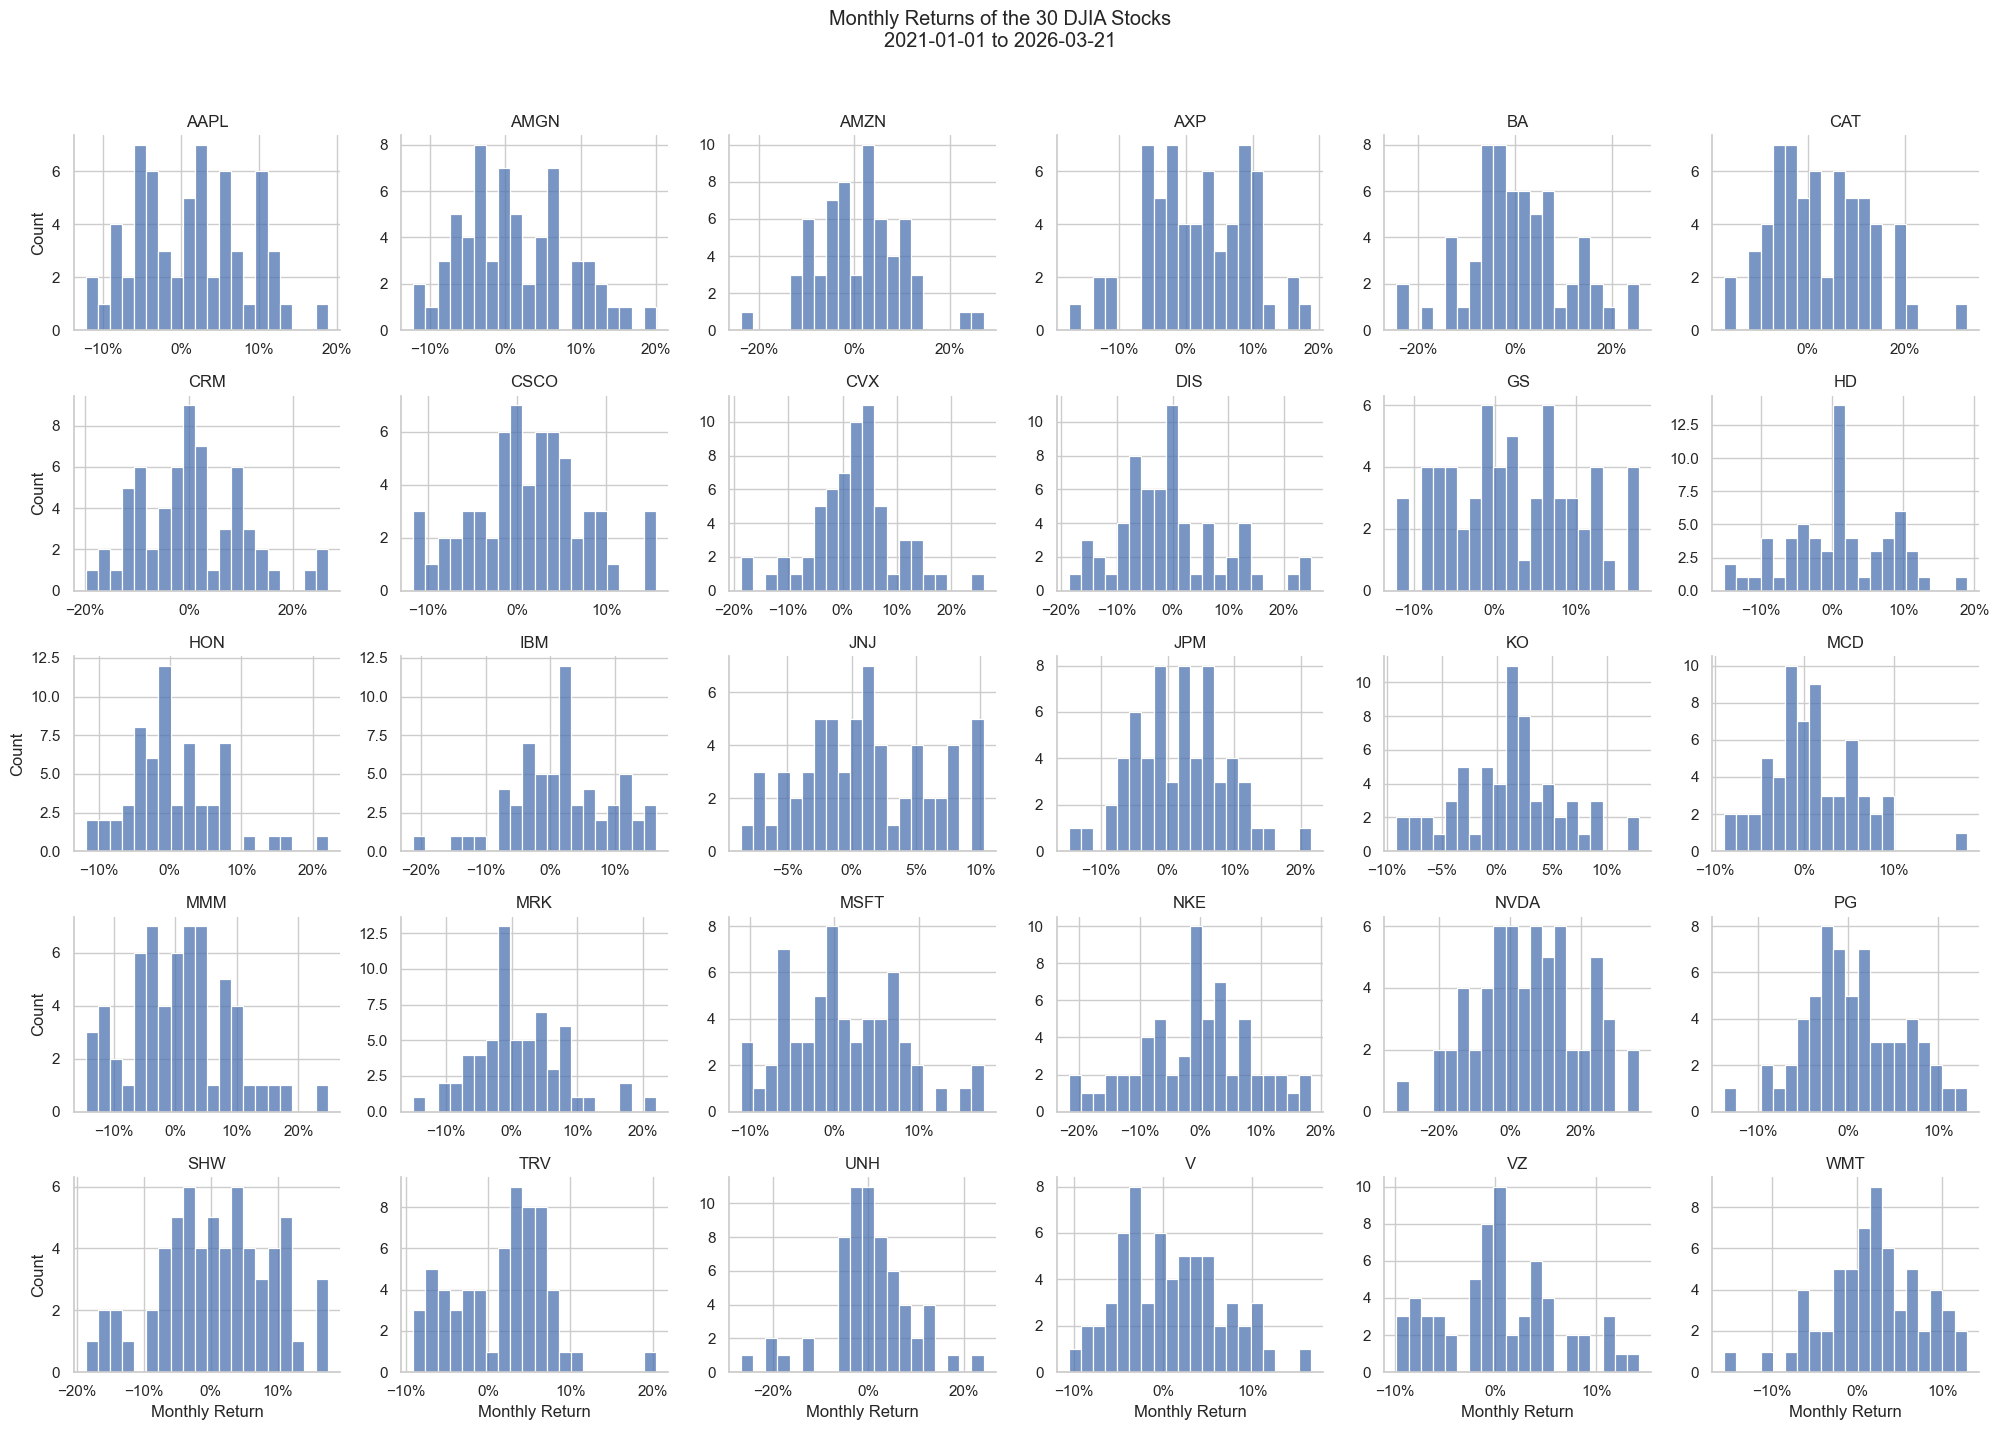

In [11]:
# --- Histogram of monthly returns, faceted by stock ---
# Exclude SPY so we see only the 30 DJIA components

plot_data = monthly_returns[monthly_returns['symbol'] != 'SPY']

g = sns.FacetGrid(
    plot_data,
    col='symbol',
    col_wrap=6,
    sharey=False, sharex=False,
    height=2.8, aspect=1.2
)
g.map(sns.histplot, 'monthly_returns', bins=20, kde=False)
g.set_axis_labels('Monthly Return', 'Count')
g.set_titles('{col_name}')

# Format x-axis ticks as percentages
for ax in g.axes.flatten():
    ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))

g.figure.suptitle(
    f'Monthly Returns of the 30 DJIA Stocks\n{start_date} to {end_date}',
    y=1.02
)
plt.tight_layout()
plt.show()

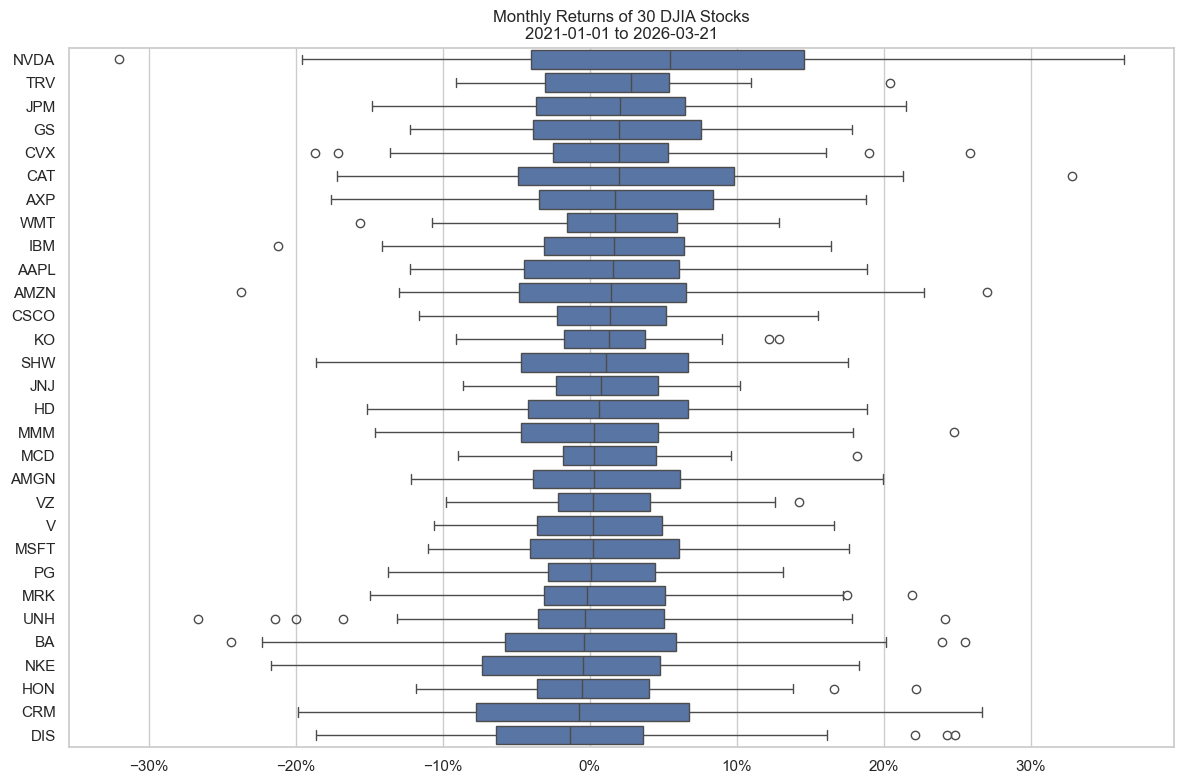

In [12]:
# --- Boxplot: monthly returns, stocks ordered by median return ---
# We replicate this by computing the median per stock and sorting

median_order = (
    plot_data
    .groupby('symbol')['monthly_returns']
    .median()
    .sort_values(ascending=False)
    .index.tolist()
)

fig, ax = plt.subplots(figsize=(12, 8))
sns.boxplot(
    data=plot_data,
    x='monthly_returns',
    y='symbol',
    order=median_order,    # sorted by median (ascending)
    ax=ax
)
ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
ax.set_xlabel('')
ax.set_ylabel('')
ax.set_title(f'Monthly Returns of 30 DJIA Stocks\n{start_date} to {end_date}')
plt.tight_layout()
plt.show()

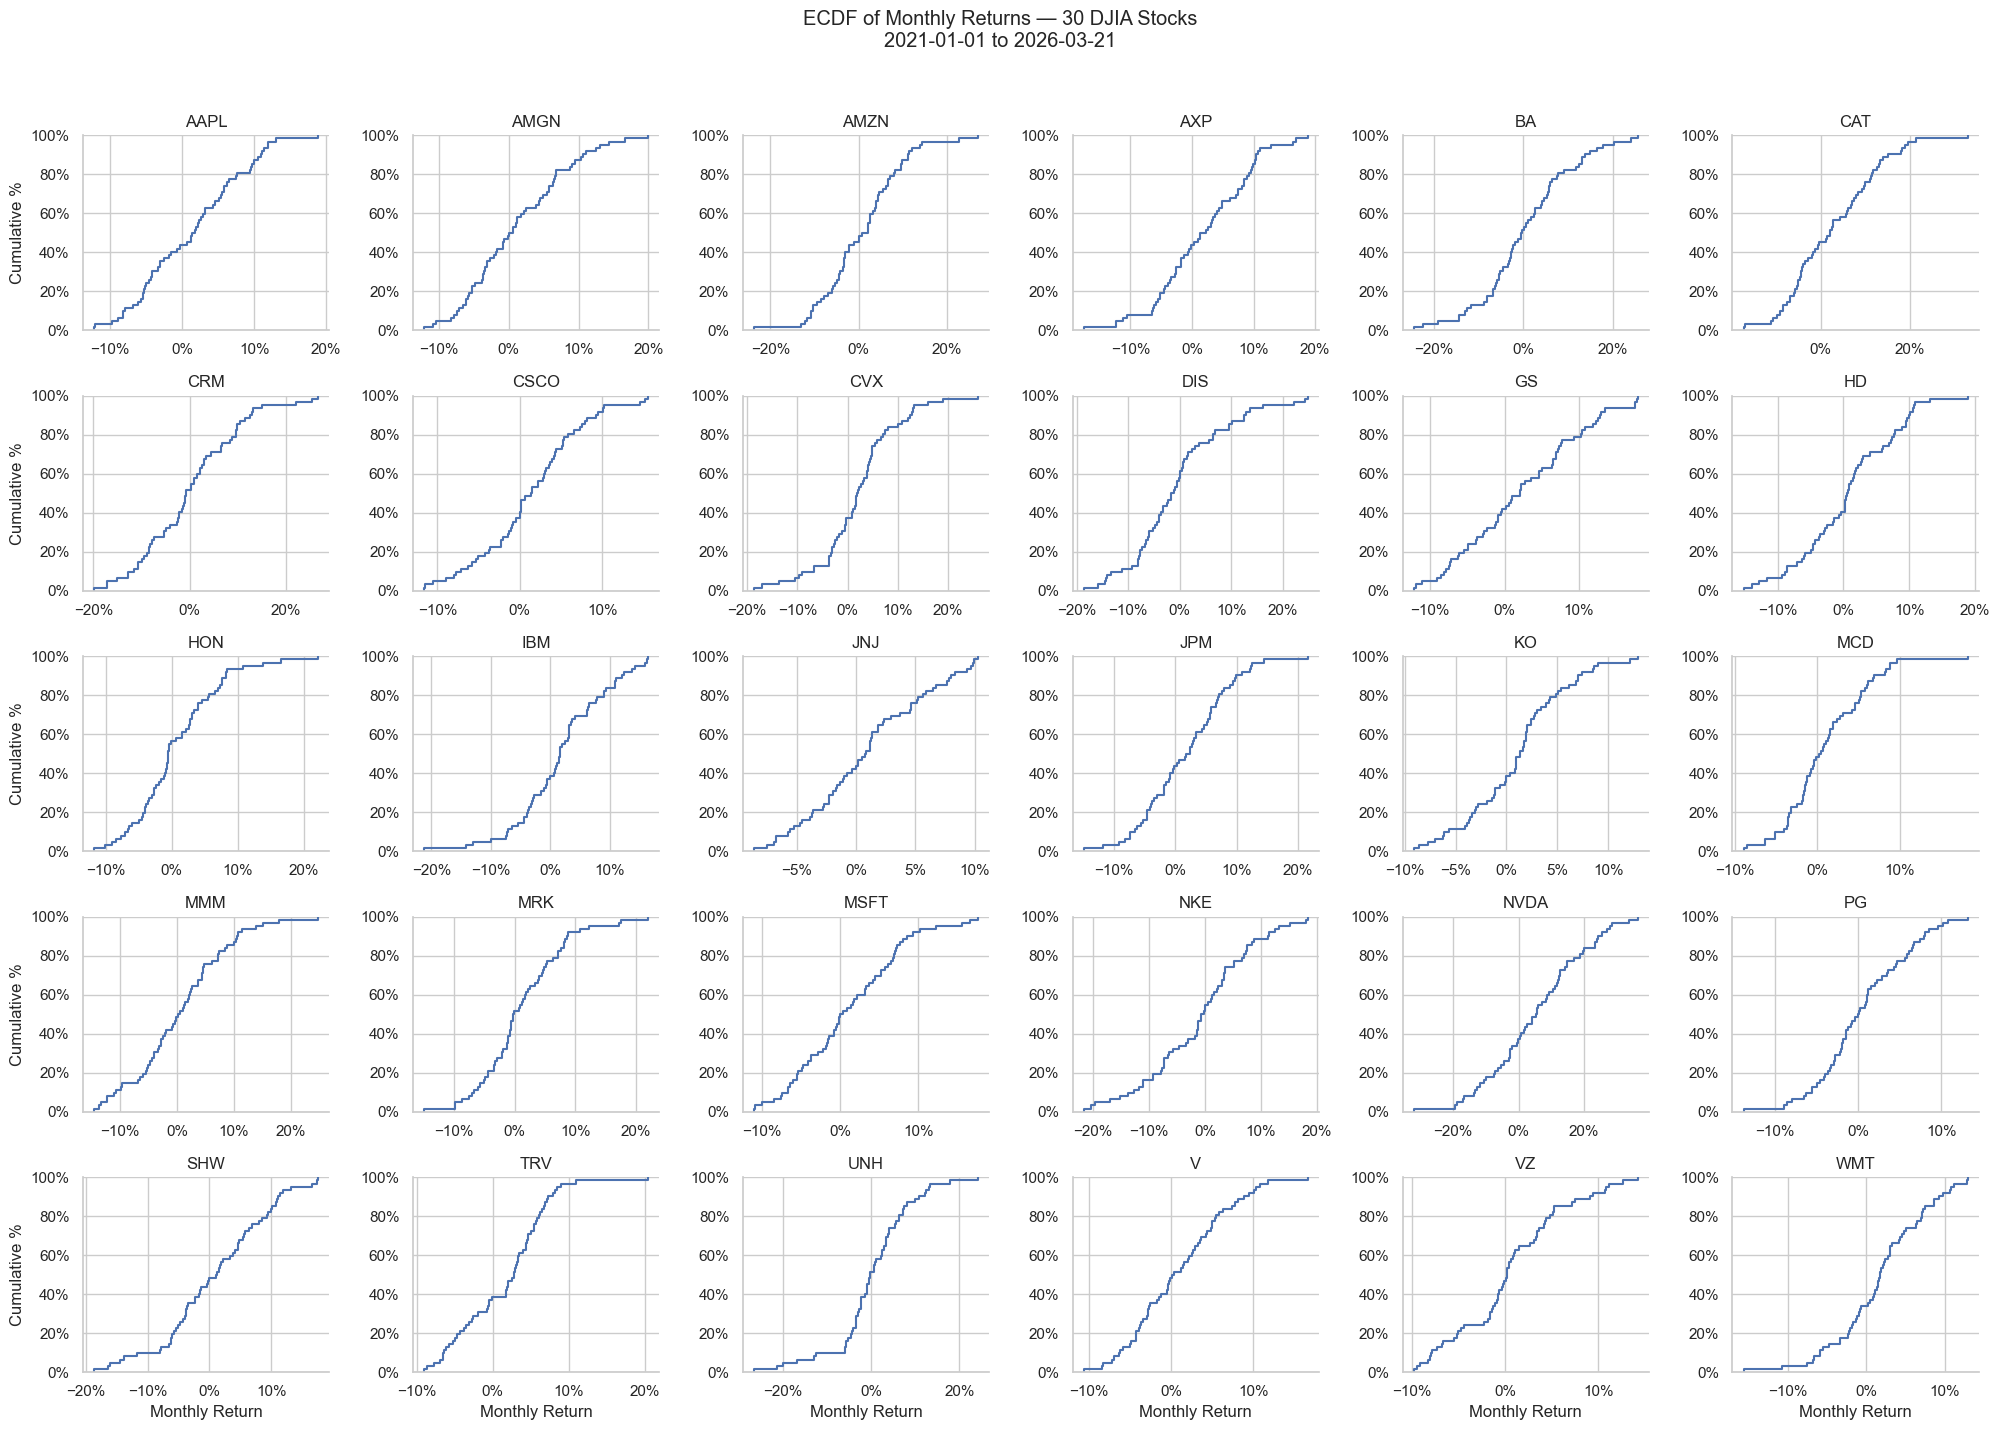

In [13]:
# --- ECDF of monthly returns, faceted by stock ---

g = sns.FacetGrid(
    plot_data,
    col='symbol',
    col_wrap=6,
    sharey=False, sharex=False,
    height=2.8, aspect=1.2
)
g.map(sns.ecdfplot, 'monthly_returns')
g.set_axis_labels('Monthly Return', 'Cumulative %')
g.set_titles('{col_name}')

for ax in g.axes.flatten():
    ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))

g.figure.suptitle(
    f'ECDF of Monthly Returns — 30 DJIA Stocks\n{start_date} to {end_date}',
    y=1.02
)
plt.tight_layout()
plt.show()

In [14]:
# --- Summary table: mean, SD, 95% CI per stock ---

from scipy import stats as scipy_stats

monthly_summaries = (
    monthly_returns
    .groupby('symbol')['monthly_returns']
    .agg(
        count='count',
        mean_return='mean',
        sd_return='std',
        min_return='min',
        max_return='max'
    )
    .assign(
        se_return=lambda df: df['sd_return'] / np.sqrt(df['count']),
        # t-critical value for a two-tailed 95% interval
        t_crit=lambda df: df['count'].apply(lambda n: scipy_stats.t.ppf(0.975, df=n-1)),
    )
    .assign(
        lower_95=lambda df: df['mean_return'] - df['t_crit'] * df['se_return'],
        upper_95=lambda df: df['mean_return'] + df['t_crit'] * df['se_return'],
    )
    .sort_values('mean_return', ascending=False)
    .round(4)
)

print('Summary statistics per stock (top 10 by mean return):')
monthly_summaries.head(10)

Summary statistics per stock (top 10 by mean return):


,count,mean_return,sd_return,min_return,max_return,se_return,t_crit,lower_95,upper_95
symbol,,,,,,,,,
NVDA,62,0.0528,0.1452,-0.3203,0.3634,0.0184,1.9996,0.0159,0.0897
CAT,62,0.0277,0.1003,-0.1718,0.3281,0.0127,1.9996,0.0022,0.0532
GS,62,0.0230,0.0802,-0.1221,0.1787,0.0102,1.9996,0.0026,0.0434
CVX,62,0.0207,0.0796,-0.1867,0.2591,0.0101,1.9996,0.0005,0.0409
AXP,62,0.0190,0.0770,-0.1758,0.1881,0.0098,1.9996,-0.0005,0.0386
IBM,62,0.0186,0.0761,-0.2123,0.1640,0.0097,1.9996,-0.0008,0.0379
WMT,62,0.0179,0.0574,-0.1562,0.1287,0.0073,1.9996,0.0033,0.0325
JPM,62,0.0174,0.0692,-0.1484,0.2154,0.0088,1.9996,-0.0002,0.0350
TRV,62,0.0159,0.0566,-0.0907,0.2040,0.0072,1.9996,0.0015,0.0302


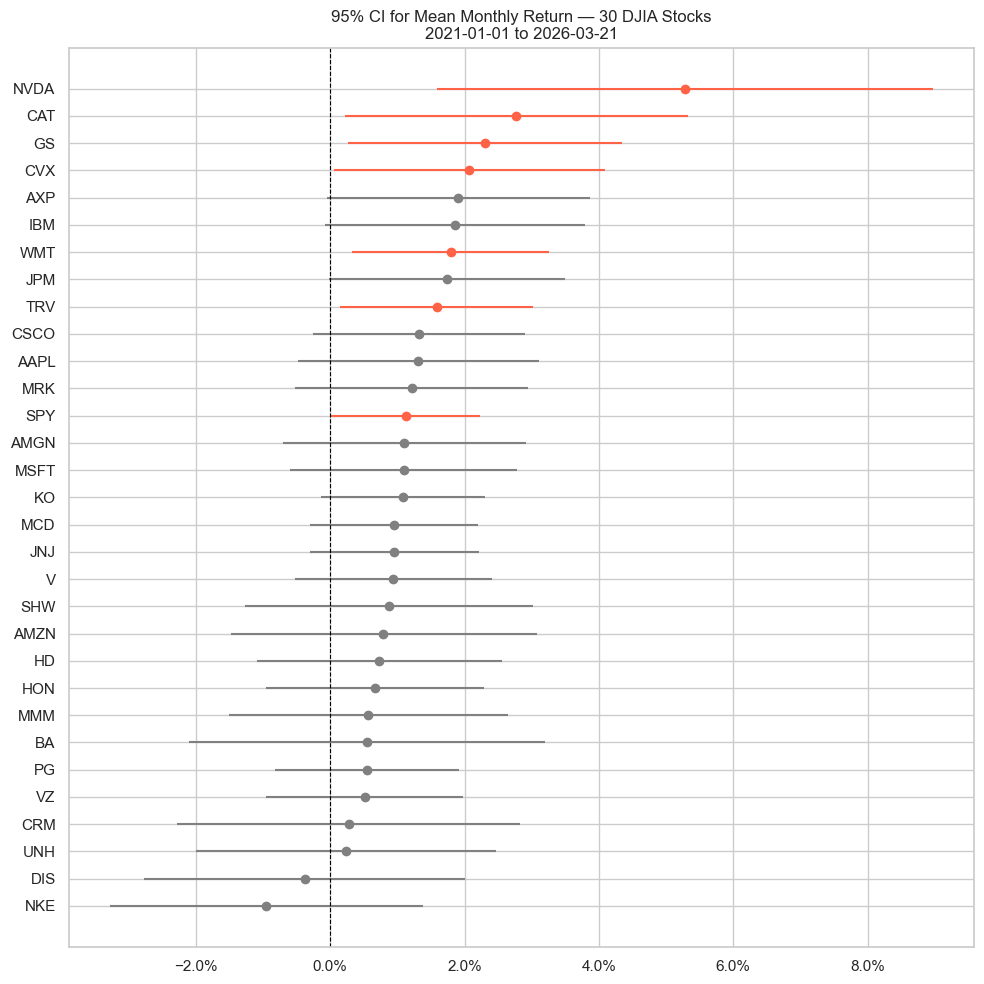

In [15]:
# --- 95% CI dot-and-whisker plot ---
# Stocks whose CI crosses zero are coloured grey; those entirely above zero are tomato

ci_data = (
    monthly_summaries
    .reset_index()
    .assign(
        contains_zero=lambda df: df['lower_95'] < 0   # True if CI includes zero
    )
    .sort_values('mean_return')
)

fig, ax = plt.subplots(figsize=(10, 10))

for _, row in ci_data.iterrows():
    colour = 'grey' if row['contains_zero'] else 'tomato'
    ax.errorbar(
        x=row['mean_return'],
        y=row['symbol'],
        xerr=[[row['mean_return'] - row['lower_95']],
              [row['upper_95'] - row['mean_return']]],
        fmt='o',
        color=colour,
        markersize=6,
        linewidth=1.5
    )

ax.axvline(0, color='black', linestyle='--', linewidth=0.8)
ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=1))
ax.set_xlabel('')
ax.set_ylabel('')
ax.set_title(f'95% CI for Mean Monthly Return — 30 DJIA Stocks\n{start_date} to {end_date}')
plt.tight_layout()
plt.show()

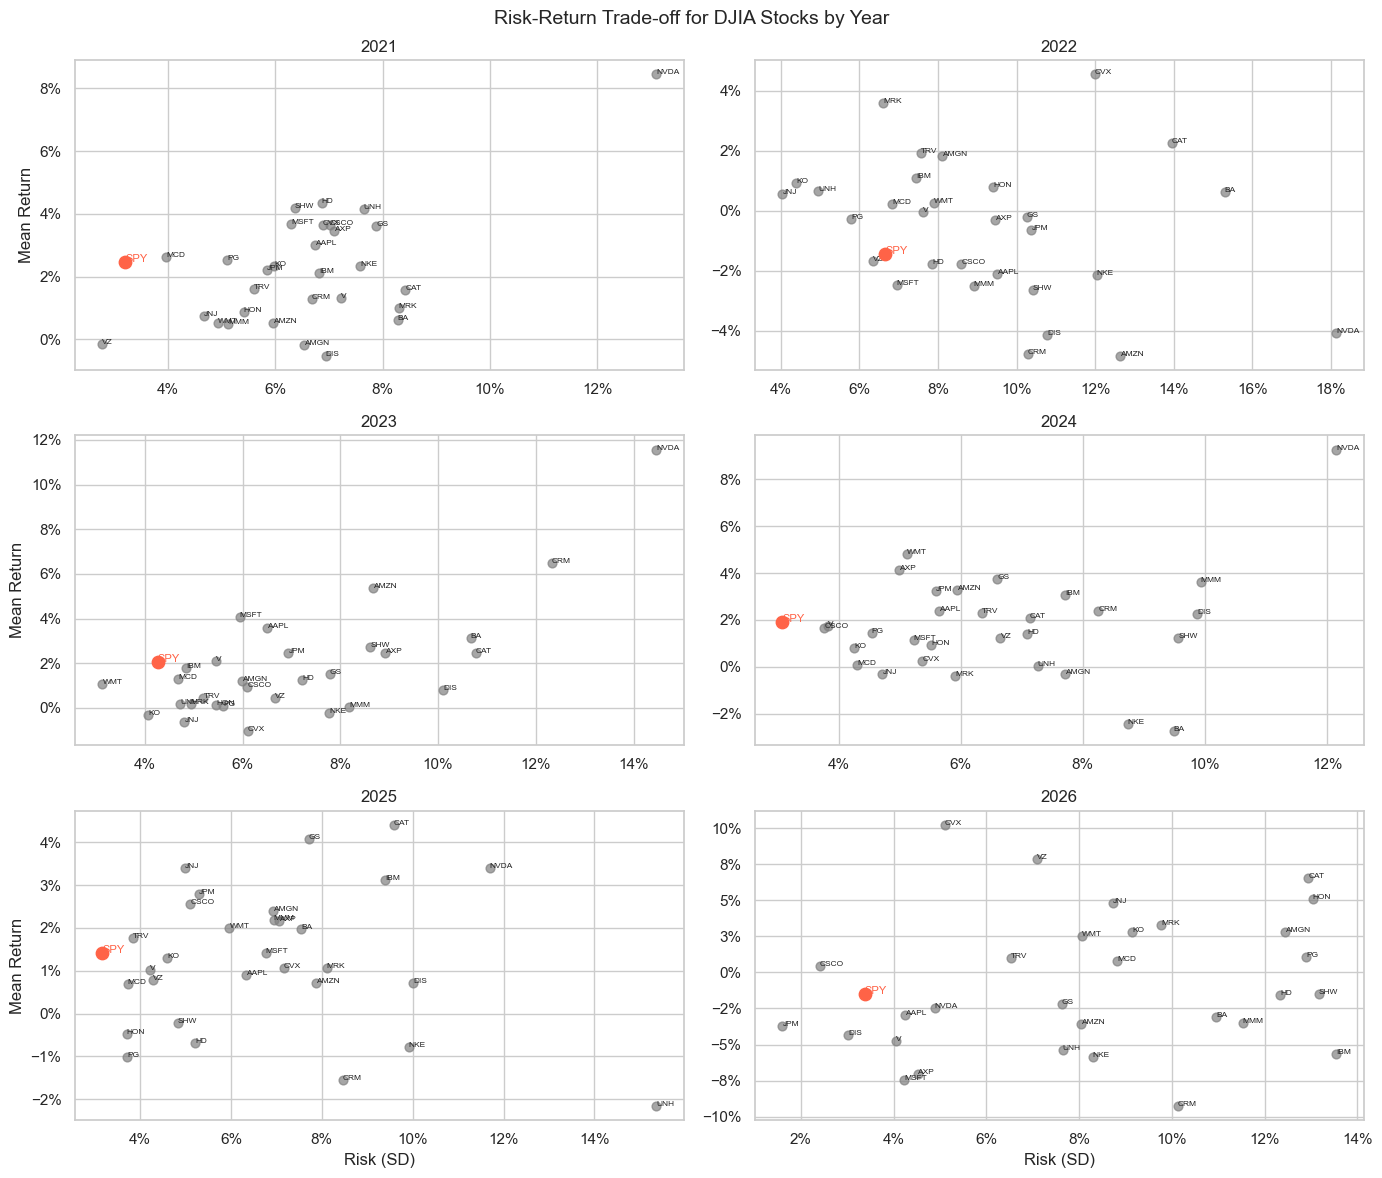

In [16]:
# --- Risk-Return scatter faceted by year ---
# Risk = SD of monthly returns; Return = mean monthly return
# Each point is one stock; SPY highlighted in tomato

by_year = (
    monthly_returns
    .assign(year=lambda df: df['date'].dt.year)
    .groupby(['year', 'symbol'])['monthly_returns']
    .agg(mean_return='mean', sd_return='std')
    .reset_index()
    .assign(is_spy=lambda df: df['symbol'] == 'SPY')
)

years = sorted(by_year['year'].unique())
n_years = len(years)
cols = 2
rows = (n_years + 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(14, 4 * rows))
axes = axes.flatten()

for i, year in enumerate(years):
    ax   = axes[i]
    data = by_year[by_year['year'] == year]
    # Non-SPY stocks
    ax.scatter(
        data.loc[~data['is_spy'], 'sd_return'],
        data.loc[~data['is_spy'], 'mean_return'],
        color='grey', alpha=0.7, s=40
    )
    # Label each non-SPY stock
    for _, r in data[~data['is_spy']].iterrows():
        ax.text(r['sd_return'], r['mean_return'], r['symbol'], fontsize=6, ha='left')
    # SPY benchmark
    spy_row = data[data['is_spy']]
    if not spy_row.empty:
        ax.scatter(spy_row['sd_return'], spy_row['mean_return'],
                   color='tomato', s=80, zorder=5)
        ax.text(spy_row['sd_return'].iloc[0], spy_row['mean_return'].iloc[0],
                'SPY', fontsize=8, color='tomato', ha='left')
    ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
    ax.set_title(str(year))
    ax.set_xlabel('Risk (SD)' if i >= (rows-1)*cols else '')
    ax.set_ylabel('Mean Return' if i % cols == 0 else '')

# Hide empty subplots
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Risk-Return Trade-off for DJIA Stocks by Year', fontsize=14)
plt.tight_layout()
plt.show()

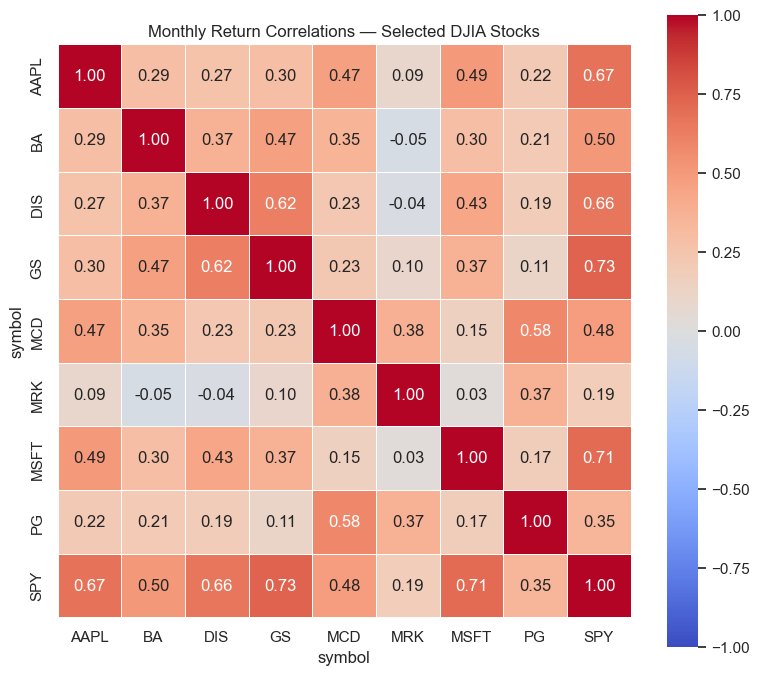

In [17]:
# --- Correlation-scatterplot matrix for selected stocks ---

selected = ['SPY', 'AAPL', 'BA', 'DIS', 'PG', 'GS', 'MCD', 'MRK', 'MSFT']

corr_pivot = (
    monthly_returns
    .loc[monthly_returns['symbol'].isin(selected)]
    .pivot_table(index='date', columns='symbol', values='monthly_returns')
    .dropna()
)

fig, ax = plt.subplots(figsize=(8, 7))

sns.heatmap(
    corr_pivot.corr(),
    annot=True, fmt='.2f',
    cmap='coolwarm', center=0, vmin=-1, vmax=1,
    square=True, linewidths=0.5,
    ax=ax
)

ax.set_title('Monthly Return Correlations — Selected DJIA Stocks')
plt.tight_layout()
plt.show()

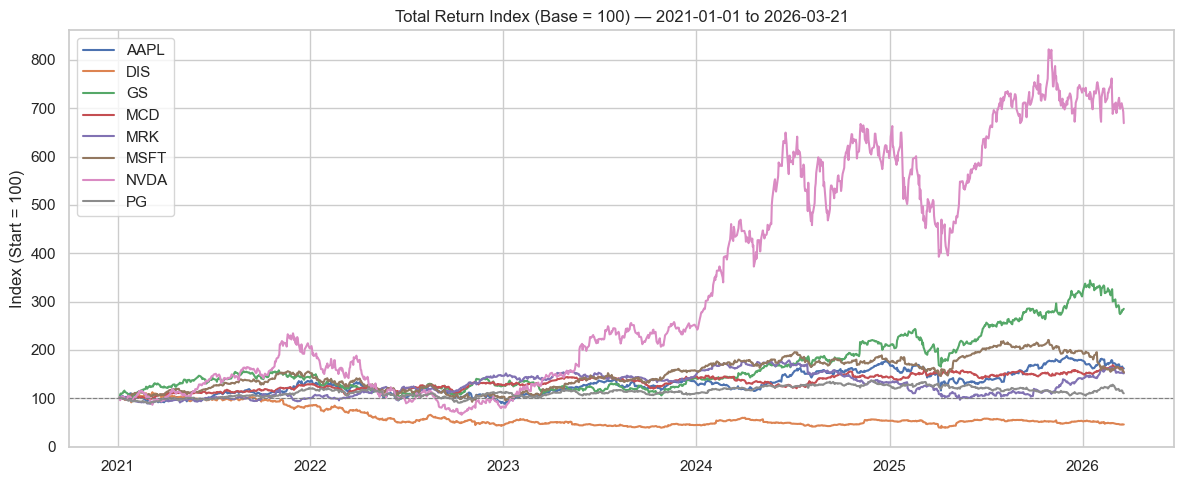

In [19]:
# =============================================================================
# SECTION: Total Return Index — growth of $100 invested
# =============================================================================
# A "total return index" answers: "If I invested $100 in this stock on Day 1,
# how much would it be worth each day?"
#
# This converts raw return data into an intuitive dollar-value narrative.
#
# FORMULA:
#   index_value_t = 100 × Π(1 + r_i) for i from 1 to t
#
#   Where Π = cumulative product, r_i = daily log return on day i
#   (For log returns: 1 + log_return ≈ 1 + simple_return for small returns)
#
# KEY OPERATION: .cumprod()
# ==========================
# .cumprod() = cumulative product: each value is the product of all previous values
#
#   Example with daily returns:
#     Day 1: +2%  → (1 + 0.02) = 1.02          → 100 × 1.02       = 102.00
#     Day 2: +3%  → 1.02 × 1.03                → 100 × 1.05       = 105.00 (approx)
#     Day 3: −1%  → 1.02 × 1.03 × 0.99         → 100 × 1.04       = 104.00 (approx)
#
#   (1 + daily_returns).cumprod():
#   1. Add 1 to each daily return: e.g. −0.034 becomes 0.966
#      (multiplying by 0.966 = losing 3.4% of current value)
#   2. .cumprod(): multiply these factors cumulatively
#   3. × 100: scale to "starting at $100"
#
# WHY START AT 100?
#   Starting all stocks at 100 puts them on the same scale.
#   At any date, a stock at 150 has gained 50% since the start;
#   a stock at 80 has lost 20%. Easy to compare!
#
# .transform() is used here (instead of .apply()) because transform preserves
# the row alignment — the result stays in sync with the original DataFrame.

selected_tr = ['AAPL', 'MSFT', 'GS', 'PG', 'MCD', 'MRK', 'DIS', 'NVDA']

total_returns_norm = (
    daily_returns
    .loc[daily_returns['symbol'].isin(selected_tr)]
    .sort_values(['symbol', 'date'])
    .assign(
        # (1 + r).cumprod() computes the cumulative growth factor
        # Multiplied by 100 → index starting at $100
        total_return=lambda df: df.groupby('symbol')['daily_returns']
                                   .transform(lambda x: 100 * (1 + x).cumprod())
    )
)

fig, ax = plt.subplots(figsize=(12, 5))

sns.lineplot(
    data=total_returns_norm,
    x='date', y='total_return',
    hue='symbol',           # one line per stock, each in a different colour
    ax=ax
)

# Reference line at 100 = "break even" — below this = lost money since start
ax.axhline(100, color='grey', linestyle='--', linewidth=0.8)
ax.set_xlabel('')
ax.set_ylabel('Index (Start = 100)')
ax.legend(title='')
ax.set_title(f'Total Return Index (Base = 100) — {start_date} to {end_date}')
plt.tight_layout()
plt.show()

# WHAT TO LOOK FOR:
#   - Which stocks are above 100? (positive total return over the period)
#   - Which dipped below 100 and never recovered?
#   - How do they compare to each other over time?